# 1.1 FIR Filter

Часть 1 проекта по активному шумоподавлению. Общая идея: микрофон ловит звук → bandpass-фильтр выделяет узкую полосу шума → инвертор крутит её на −1 → динамик играет противофазу → шум в этой полосе физически гасится. Тут собираю саму математику фильтра и проверяю, что он работает как надо.

Параметры по ТЗ: **bandpass 2500–3500 Hz**, **fs = 48 kHz** (стандарт для I2S с INMP441), длина $N = 101$ tap.

Делаем три эксперимента из ТЗ: чистая музыка, музыка с писком в полосе фильтра, и равномерный шум. Для каждого — спектрограмма до и после, итого 6 штук.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz, lfilter, spectrogram
from IPython.display import Audio, display

from filter_anc.signals import synth_music, music_with_beep, white_noise, load_wav

FS = 48_000
F1, F2 = 2_500, 3_500
N = 101

## 1.1.1 FIR filter

`firwin` строит коэффициенты bandpass-фильтра методом окна: берёт идеальный (sinc) импульсный отклик и обрезает его конечным окном Хэмминга. На выходе массив `b` длины N — это и есть коэффициенты, которые потом будут жить в Verilog как `B_TAPS`.

Важно: `N` должно быть нечётным (чтобы фильтр был симметричным и с линейной фазой) и `pass_zero=False` (иначе по умолчанию получится bandstop). `sum(b)` должна быть около нуля — bandpass не пропускает постоянную составляющую.

In [2]:
b = firwin(N, [F1, F2], pass_zero=False, window="hamming", fs=FS)
print(b.shape, b.sum(), b.max())

## 1.1.2 характеристики

Два стандартных графика по фильтру:

- **АЧХ** — `freqz` считает $|H(f)|$ в дБ. Должна быть горка внутри 2.5–3.5 кГц около 0 дБ и провал ниже −40 дБ снаружи — это значит фильтр реально режет, а не делает вид.
- **Импульсная характеристика** — это просто сами коэффициенты `b`, по определению FIR. По стему видно симметрию (значит линейная фаза) и sinc-овую форму, обрезанную окном.

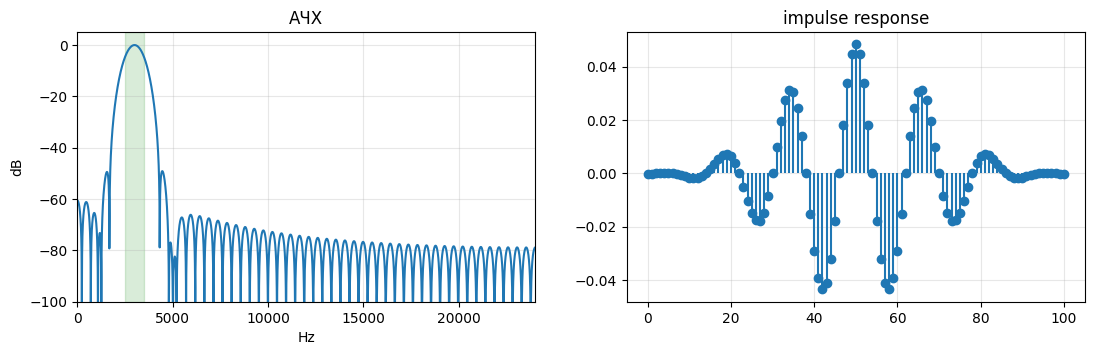

In [3]:
w, h = freqz(b, worN=4096, fs=FS)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
ax[0].plot(w, 20*np.log10(np.abs(h)+1e-12))
ax[0].axvspan(F1, F2, alpha=0.15, color="g")
ax[0].set_xlim(0, FS/2); ax[0].set_ylim(-100, 5)
ax[0].set_xlabel("Hz"); ax[0].set_ylabel("dB"); ax[0].set_title("АЧХ"); ax[0].grid(alpha=.3)

ax[1].stem(b, basefmt=" ")
ax[1].set_title("impulse response"); ax[1].grid(alpha=.3)
plt.show()

## 1.1.3 эксперименты

Три сигнала из ТЗ, каждый по-своему проверяет фильтр:

1. **Музыка** — в нашей полосе 2.5–3.5 кГц контента почти нет, так что после фильтра должно получиться почти ничего. Проверка, что фильтр не пропускает мимо то, что не надо.
2. **Музыка + писк (3 кГц)** — писк попадает ровно в середину полосы. Фильтр должен вытащить именно его, и оставить только его. Это и есть "шумовая компонентаЭ, которую FPGA потом инвертирует и пошлёт в динамик.
3. **Белый шум** — энергия размазана по всему спектру. После фильтра должна остаться узкая полоса именно в 2.5–3.5 кГц. Самый наглядный тест.

Применяю через `scipy.signal.lfilter(b, [1.0], x)` — для FIR в знаменателе только `1`, полюсов нет.

In [4]:
data = Path.cwd().parent / "data"
if (data / "music.wav").exists():
    music, _ = load_wav(data / "music.wav")
    beep,  _ = load_wav(data / "music_beep.wav")
    noise, _ = load_wav(data / "white_noise.wav")
else:
    music = synth_music(5, FS)
    beep  = music_with_beep(5, FS, beep_hz=3_000)
    noise = white_noise(5, FS)

sigs = {"I. music": music, "II. music+beep": beep, "III. noise": noise}
out  = {k: lfilter(b, [1.0], v) for k, v in sigs.items()}

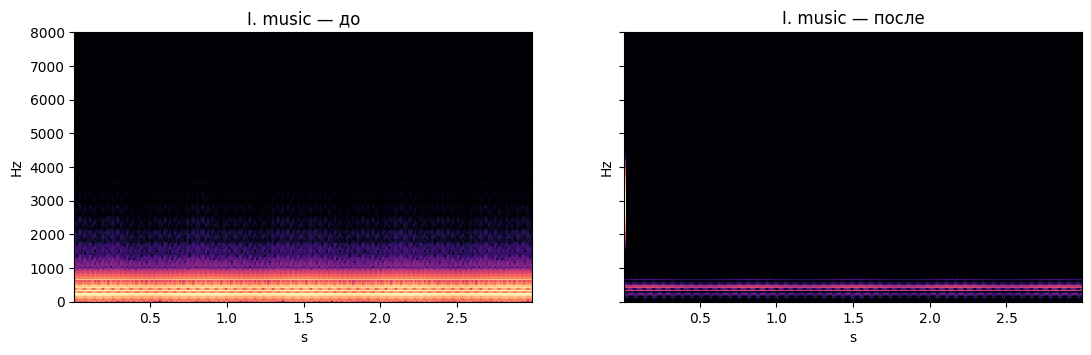

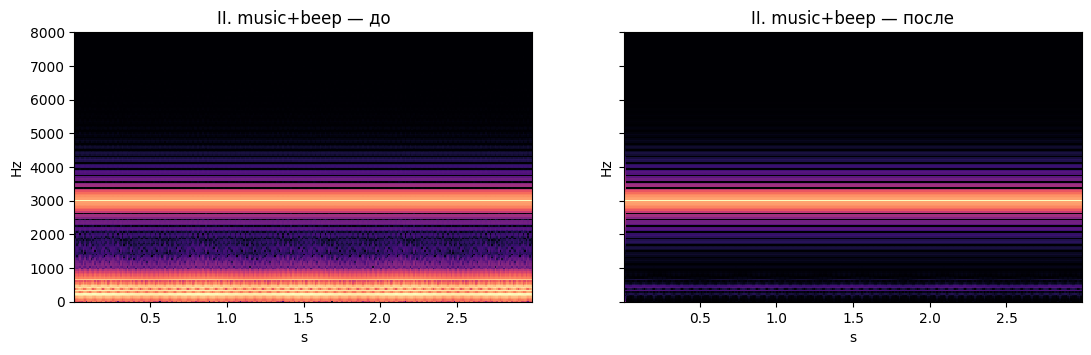

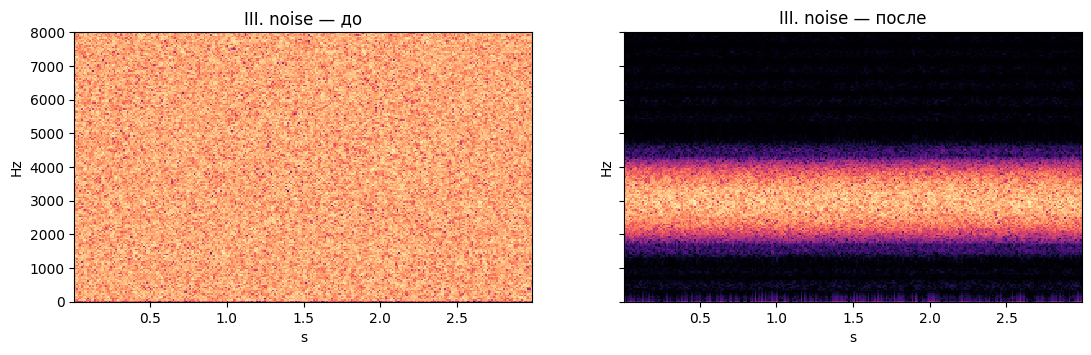

In [5]:
def spec(ax, x, title):
    f, t, S = spectrogram(x, fs=FS, nperseg=1024, noverlap=512)
    ax.pcolormesh(t, f, 10*np.log10(S+1e-12), shading="auto", cmap="magma")
    ax.set_ylim(0, 8000); ax.set_title(title); ax.set_xlabel("s"); ax.set_ylabel("Hz")

for name, x in sigs.items():
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
    spec(ax[0], x,        f"{name} — до")
    spec(ax[1], out[name], f"{name} — после")
    plt.show()

In [6]:
for name in sigs:
    print(name)
    display(Audio(sigs[name], rate=FS, normalize=True))
    display(Audio(out[name],  rate=FS, normalize=True))

I. music


II. music+beep


III. noise


### что вышло

- **I. музыка** — после фильтра почти тишина. Правильно, в полосе 2.5–3.5 кГц у синтезированной музыки контента и не было.
- **II. музыка + писк** — до: видно жёлтую полосу на 3 кГц и всю остальную гармонику снизу. После: остался только сам писк, всё остальное обрезано. Если это инвертировать и подмешать обратно — писк погасится. Это и есть смысл всего проекта.
- **III. белый шум** — на «до» спектр равномерно жёлтый, на «после» осталась узкая горизонтальная полоса именно между 2.5 и 3.5 кГц. Самая чёткая демонстрация, что фильтр режет ровно туда, куда задали.

По аудио на слух тоже всё ок: после фильтра во всех трёх случаях слышно характерное «телефонное» звучание (узкополосный звук в районе 3 кГц), без низов и без высоких.

Дальше идут шаги по подготовке этого фильтра к FPGA: 16-битная арифметика, интерактивный UI и сам Verilog-проект.